# The LLAMA of WallStreet: LLM Data Extraction and Sentiment Analysis

**Team Project – Big Data Laboratory, Bologna Business School 2026**

---

## Overview

This notebook implements a full Reddit sentiment analysis pipeline for algorithmic trading:

1. **Ticker extraction** — identify which comments mention publicly traded companies  
2. **Sentiment analysis** — classify each comment as Very Positive → Very Negative  
3. **Aggregation** — compute daily sentiment scores per ticker  
4. **Metrics** — min, max, mean, std per ticker per day  
5. **Visualisation** — plot sentiment trends (Boeing-style chart)  
6. **SLURM agent design** — architecture for agentic HPC job management  
7. **SLURM agent implementation** — optional working agent  

> **Note:** The pipeline is tested on `LIMIT = 1000` comments in this notebook.  
> For full scale, increase `LIMIT` or use `student_job_LLM.py` as a SLURM batch job.


## Imports

In [1]:
from datetime import datetime
from enum import Enum
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import json
import subprocess
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pydantic import BaseModel

from langchain_openai import ChatOpenAI


## Configuration

The LLM is served locally by vLLM on the GPU nodes.  
`LIMIT` controls how many comments to sample — start small (1000) for testing.


In [2]:
t0 = datetime.now()
print(f"Execution started: {t0}")

INPUT_FILE = "../hpc_bbs_26/team_project/llm/reddit_comments.csv"

# Model served by vLLM on Leonardo
MODEL_NAME = "mistralai/Mistral-Small-3.2-24B-Instruct-2506"
VLLM_ENDPOINT = "http://127.0.0.1:8000/v1"
API_KEY = "password"

# How many comments to process (max ~100_000)
LIMIT = 1000

# Parallelism – number of concurrent LLM requests
MAX_WORKERS = 8

# LangChain LLM client pointing to local vLLM server
llm = ChatOpenAI(base_url=VLLM_ENDPOINT, api_key=API_KEY, model=MODEL_NAME)

print(f"Model: {MODEL_NAME}")
print(f"Processing {LIMIT} comments with {MAX_WORKERS} parallel workers")


Execution started: 2026-06-20 17:09:37.521153
Model: mistralai/Mistral-Small-3.2-24B-Instruct-2506
Processing 1000 comments with 8 parallel workers


## Data Extraction Example (from original notebook)

Before building our pipeline, here is the structured-output pattern we will use.  
LangChain's `.with_structured_output(PydanticModel)` forces the LLM to respond
in a validated, typed Python object — no regex needed.


In [ ]:
# ── Example: extract legal citations with structured outputs ──────────────
EXAMPLE_SYSTEM_PROMPT = """You are a helpful assistant trained to extract law citations
from legal proceedings. Extract citations as: article number + law collection name.
Law collection options: United States Code, Code of Federal Regulations, NA.

Examples:
[INPUT]: Tomorrow I have an exam about USC art. 1
[OUTPUT]: [{"article": "1", "code": "United States Code"}]
[INPUT]: I like pizza!
[OUTPUT]: [{"article": "NA", "code": "NA"}]
"""

class Codes(Enum):
    USC = "United States Code"
    CFR = "Code of Federal Regulations"
    NA = "NA"

class Citation(BaseModel):
    article: str
    code: Codes

class Citations(BaseModel):
    citations: list[Citation]

# example_result = llm.with_structured_output(Citations).invoke(
#     input=[
#         {"role": "system", "content": EXAMPLE_SYSTEM_PROMPT},
#         {"role": "user", "content": "Did you study article 33 of the USC and article 3475-bis of USC?"},
#     ]
# )
# for c in example_result.citations:
#     print(f"Article: {c.article}  |  Code: {c.code.value}")


## Step 1 — Read Data

The dataset contains ~100k Reddit comments with columns:
- `datetime` — timestamp of the comment  
- `subreddits` — subreddit name  
- `submission_id` — post ID  
- `comments` — raw comment text  


In [3]:
df_raw = pd.read_csv(INPUT_FILE)
print(f"Total comments in CSV: {len(df_raw):,}")
print(f"\nColumn dtypes:\n{df_raw.dtypes}")
print(f"\nDate range: {df_raw['datetime'].min()} → {df_raw['datetime'].max()}")
print(f"\nSubreddits:\n{df_raw['subreddits'].value_counts().to_string()}")
df_raw.head()


Total comments in CSV: 101,974

Column dtypes:
datetime         str
subreddits       str
submission_id    str
comments         str
dtype: object

Date range: 2024-01-27 20:02:47 → 2025-04-11 15:54:37

Subreddits:
subreddits
news        101752
technews       222


,datetime,subreddits,submission_id,comments
0,2025-03-29 18:32:13,news,1jmrj8p,A British man has been praised for tackling a ...
1,2025-03-29 18:32:13,news,1jmrj8p,Glad they recognized him. He did a great thing.
2,2025-03-29 18:32:13,news,1jmrj8p,A news on a British tourist that doesn't invol...
3,2025-03-29 18:32:13,news,1jmrj8p,That guys needs some real love. Hopefully he A...
4,2025-03-29 18:32:13,news,1jmrj8p,"“I’m Millwall, mate”. Probably"


In [ ]:
# df_raw.tail(51974).to_csv("reddit_comments_tail.csv", index=False)

In [4]:
# Sample LIMIT comments for this notebook run
# df = df_raw.sample(n=LIMIT, random_state=42).reset_index(drop=True)
df = df_raw.head(1000).copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = df["datetime"].dt.date

print(f"Working with {len(df):,} comments")
print(f"Date range in sample: {df['date'].min()} → {df['date'].max()}")
df.head()


Working with 1,000 comments
Date range in sample: 2024-02-06 → 2025-03-29


,datetime,subreddits,submission_id,comments,date
0,2025-03-29 18:32:13,news,1jmrj8p,A British man has been praised for tackling a ...,2025-03-29
1,2025-03-29 18:32:13,news,1jmrj8p,Glad they recognized him. He did a great thing.,2025-03-29
2,2025-03-29 18:32:13,news,1jmrj8p,A news on a British tourist that doesn't invol...,2025-03-29
3,2025-03-29 18:32:13,news,1jmrj8p,That guys needs some real love. Hopefully he A...,2025-03-29
4,2025-03-29 18:32:13,news,1jmrj8p,"“I’m Millwall, mate”. Probably",2025-03-29


## Step 2 & 3 — Ticker Extraction + Sentiment Analysis (Combined LLM Call)

We combine both tasks into **a single LLM call per comment** to halve the number of
API requests. The model returns:
- `tickers`: list of stock ticker symbols (empty list if the comment is not about any traded company)  
- `sentiment`: one of five levels  

We use Pydantic `BaseModel` + `Enum` for structured outputs.


In [5]:
# ── Pydantic schema for structured output ────────────────────────────────────

class SentimentLevel(str, Enum):
    very_positive = "very_positive"
    positive = "positive"
    neutral = "neutral"
    negative = "negative"
    very_negative = "very_negative"

class CommentAnalysis(BaseModel):
    """
    Result of analysing one Reddit comment.
    tickers: list of stock ticker symbols mentioned (e.g. ['AAPL', 'MSFT']).
             Empty list [] if the comment is not about any publicly traded company.
    sentiment: overall sentiment towards the mentioned companies.
               Use 'neutral' if tickers is empty.
    """
    tickers: list[str]
    sentiment: SentimentLevel


# ── Sentiment → integer mapping ──────────────────────────────────────────────
SENTIMENT_MAP = {
    "very_positive":  2,
    "positive":       1,
    "neutral":        0,
    "negative":      -1,
    "very_negative": -2,
}

# ── System prompt ─────────────────────────────────────────────────────────────
ANALYSIS_SYSTEM_PROMPT = """You are a financial data extraction assistant specialising in social media analysis.

Your task is to analyse a Reddit comment and return TWO pieces of information:

1. TICKERS: A list of stock ticker symbols for any publicly traded companies mentioned.
   - Only include companies actually traded on a major stock exchange (NYSE, NASDAQ, etc.)
   - Use the official ticker symbol (e.g. Apple → AAPL, Tesla → TSLA, Microsoft → MSFT)
   - Return an empty list [] if no company is mentioned or the company is not publicly traded
   - A comment about general news, politics, sports, or everyday life → empty list

2. SENTIMENT: The overall sentiment expressed towards those companies.
   - very_positive: extremely bullish, strong buy signals, very optimistic
   - positive: generally optimistic, mildly bullish
   - neutral: balanced view, factual, no clear direction
   - negative: pessimistic, bearish, concerned
   - very_negative: extremely bearish, very negative outlook, panic selling
   - If tickers is empty, always return neutral

Examples:
Comment: "Just loaded up on more $AAPL calls, this earnings will be insane"
→ tickers: ["AAPL"], sentiment: very_positive

Comment: "Tesla keeps disappointing me every quarter, I'm done holding this garbage"
→ tickers: ["TSLA"], sentiment: very_negative

Comment: "Anyone else watching MSFT and GOOGL today? MSFT looks good, GOOGL not so much"
→ tickers: ["MSFT", "GOOGL"], sentiment: neutral

Comment: "I hate Mondays"
→ tickers: [], sentiment: neutral
"""

print("Schema and system prompt defined.")
print(f"Sentiment levels: {[s.value for s in SentimentLevel]}")


Schema and system prompt defined.
Sentiment levels: ['very_positive', 'positive', 'neutral', 'negative', 'very_negative']


## Step 4 — Parallel Processing Pipeline

We process comments concurrently using `ThreadPoolExecutor`.  
Each worker sends one comment to the vLLM endpoint and returns the structured result.  
Failed requests are retried once; after that they are recorded as `null` tickers and neutral sentiment.


In [6]:
def analyse_comment(row_tuple):
    """
    Analyse a single comment. Retries once on failure.
    Returns a dict with index, tickers, sentiment_str, sentiment_score.
    """
    idx, row = row_tuple

    for attempt in range(2):
        try:
            result = llm.with_structured_output(CommentAnalysis).invoke(
                input=[
                    {"role": "system", "content": ANALYSIS_SYSTEM_PROMPT},
                    {"role": "user",   "content": str(row["comments"])[:1500]},  # truncate very long comments
                ]
            )
            return {
                "index":           idx,
                "tickers":         result.tickers,
                "sentiment_str":   result.sentiment.value,
                "sentiment_score": SENTIMENT_MAP[result.sentiment.value],
            }
        except Exception as e:
            if attempt == 0:
                time.sleep(2)  # wait before retry
            else:
                # Second failure: return empty/neutral result
                return {
                    "index":           idx,
                    "tickers":         [],
                    "sentiment_str":   "neutral",
                    "sentiment_score": 0,
                }


def run_pipeline(dataframe, max_workers=MAX_WORKERS):
    """
    Process all rows in dataframe concurrently.
    Returns a list of result dicts in original row order.
    """
    rows = list(dataframe.iterrows())
    results = [None] * len(rows)

    print(f"Processing {len(rows):,} comments with {max_workers} workers...")
    t_start = time.time()

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(analyse_comment, row_tuple): i
                   for i, row_tuple in enumerate(rows)}

        for done_count, future in enumerate(as_completed(futures), 1):
            result = future.result()
            original_pos = futures[future]
            results[original_pos] = result

            if done_count % 100 == 0 or done_count == len(rows):
                elapsed = time.time() - t_start
                rate = done_count / elapsed
                remaining = (len(rows) - done_count) / rate if rate > 0 else 0
                print(f"  {done_count:>5}/{len(rows)}  |  "
                      f"{rate:.1f} comments/s  |  "
                      f"ETA: {remaining:.0f}s")

    elapsed_total = time.time() - t_start
    print(f"\nDone! Processed {len(rows):,} comments in {elapsed_total:.1f}s "
          f"({len(rows)/elapsed_total:.1f} comments/s)")
    return results


# ── Run the pipeline ──────────────────────────────────────────────────────────
print("Starting pipeline...")
raw_results = run_pipeline(df)


## Step 5 — Build Results DataFrame

Attach the LLM output back to the original dataframe, then explode so each row
represents **one (date, ticker) pair** — enabling clean per-ticker aggregation.


In [18]:
# ── Attach results to original dataframe ─────────────────────────────────────
df["tickers"]         = [r["tickers"]         for r in raw_results]
df["sentiment_str"]   = [r["sentiment_str"]   for r in raw_results]
df["sentiment_score"] = [r["sentiment_score"] for r in raw_results]

print("Full results dataframe:")
print(df[["date", "subreddits", "tickers", "sentiment_str", "sentiment_score"]].head(10))
print(f"\nTotal comments processed: {len(df):,}")

# How many are relevant (at least one ticker)?
relevant = df[df["tickers"].apply(len) > 0]
print(f"Comments about public companies: {len(relevant):,} ({100*len(relevant)/len(df):.1f}%)")

# Save raw results
df.to_csv("results_raw.csv", index=False)
print("\nSaved: results_raw.csv")


Full results dataframe:
         date subreddits tickers sentiment_str  sentiment_score
0  2024-03-19       news      []       neutral                0
1  2024-07-13       news      []       neutral                0
2  2024-10-04       news      []       neutral                0
3  2024-03-13       news      []       neutral                0
4  2024-08-23       news      []       neutral                0
5  2024-07-24       news      []       neutral                0
6  2024-10-03       news      []       neutral                0
7  2024-06-18       news      []       neutral                0
8  2024-07-16       news      []       neutral                0
9  2024-10-03       news      []       neutral                0

Total comments processed: 1,000
Comments about public companies: 48 (4.8%)

Saved: results_raw.csv


In [19]:
# ── Keep only relevant comments (those with at least one ticker) ──────────────
df_relevant = df[df["tickers"].apply(len) > 0].copy()

# Explode: one row per ticker (a comment mentioning AAPL and MSFT → 2 rows)
df_exploded = df_relevant.explode("tickers").rename(columns={"tickers": "ticker"})
df_exploded = df_exploded[df_exploded["ticker"].str.strip() != ""]

# Normalise tickers to uppercase
df_exploded["ticker"] = df_exploded["ticker"].str.upper().str.strip()

print(f"Rows after exploding: {len(df_exploded):,}")
print(f"\nTop 20 most mentioned tickers:")
print(df_exploded["ticker"].value_counts().head(20).to_string())


Rows after exploding: 71

Top 20 most mentioned tickers:
ticker
TSLA     5
BA       4
UNH      3
AAL      3
MCD      3
AMZN     3
DAL      2
MSFT     2
SBUX     2
CMG      2
TWTR     2
JBLU     2
CRWD     1
XOM      1
VIAC     1
EBAY     1
WEN      1
MSNBC    1
RAD      1
WBA      1


## Step 6 — Daily Sentiment Aggregation & Metrics

Group by `(date, ticker)` and compute:
- `mean_sentiment` — average daily sentiment (the primary signal)
- `min_sentiment`, `max_sentiment` — range of opinions on that day
- `std_sentiment` — disagreement / volatility proxy
- `comment_count` — how many comments mentioned the ticker that day


In [20]:
daily = (
    df_exploded
    .groupby(["date", "ticker"])["sentiment_score"]
    .agg(
        mean_sentiment = "mean",
        min_sentiment  = "min",
        max_sentiment  = "max",
        std_sentiment  = "std",
        comment_count  = "count",
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["ticker", "date"])

print("Daily sentiment summary (first 20 rows):")
print(daily.head(20).to_string(index=False))

# Save
daily.to_csv("results_daily_sentiment.csv", index=False)
print("\nSaved: results_daily_sentiment.csv")


Daily sentiment summary (first 20 rows):
      date ticker  mean_sentiment  min_sentiment  max_sentiment  std_sentiment  comment_count
2024-05-13    AAL            -1.0             -1             -1            NaN              1
2024-05-24    AAL            -2.0             -2             -2            NaN              1
2024-12-24    AAL            -2.0             -2             -2            NaN              1
2024-02-26   AAPL            -1.0             -1             -1            NaN              1
2024-04-24     AC            -2.0             -2             -2            NaN              1
2024-05-13    ALK            -1.0             -1             -1            NaN              1
2024-01-30   AMZN            -1.0             -1             -1            NaN              1
2024-02-26   AMZN            -1.0             -1             -1            NaN              1
2024-10-22   AMZN            -1.0             -1             -1            NaN              1
2024-12-08   ANTM  

In [21]:
# ── Overall stats per ticker across all days ─────────────────────────────────
ticker_stats = (
    daily
    .groupby("ticker")
    .agg(
        overall_mean   = ("mean_sentiment", "mean"),
        overall_min    = ("min_sentiment",  "min"),
        overall_max    = ("max_sentiment",  "max"),
        total_comments = ("comment_count",  "sum"),
        active_days    = ("date",           "count"),
    )
    .reset_index()
    .sort_values("total_comments", ascending=False)
)

print("Overall ticker statistics:")
print(ticker_stats.head(20).to_string(index=False))


Overall ticker statistics:
ticker  overall_mean  overall_min  overall_max  total_comments  active_days
  TSLA     -1.400000           -2           -1               5            5
    BA     -1.666667           -2           -1               4            3
   AAL     -1.666667           -2           -1               3            3
   UNH     -1.750000           -2           -1               3            2
   MCD     -1.666667           -2           -1               3            3
  AMZN     -1.000000           -1           -1               3            3
  JBLU     -1.000000           -1           -1               2            2
  SBUX     -2.000000           -2           -2               2            2
   DAL     -1.500000           -2           -1               2            2
   CMG     -1.000000           -1           -1               2            2
  TWTR     -1.000000           -1           -1               2            2
  MSFT     -1.000000           -1           -1               

## Step 7 — Visualisation: Sentiment Trend Charts

For each ticker of interest we produce the Boeing-style chart from the project description:
- Blue line: daily mean sentiment  
- Green horizontal line: "Good" threshold (+1)  
- Grey horizontal line: "Neutral" (0)  
- Red horizontal line: "Bad" threshold (−1)  
- Dashed orange line: linear trend over time  


Plotting: ['AAPL', 'TSLA', 'META', 'MSFT', 'AMZN', 'BA']
Not enough data for AAPL (1 day(s)), skipping.
Saved: TSLA_sentiment.png


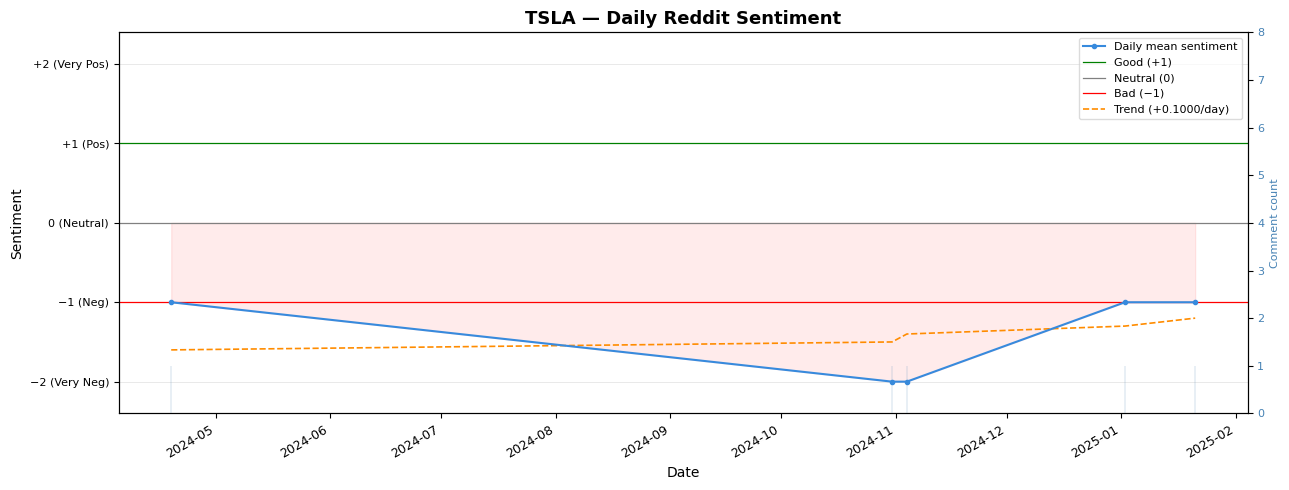

Not enough data for META (1 day(s)), skipping.
Saved: MSFT_sentiment.png


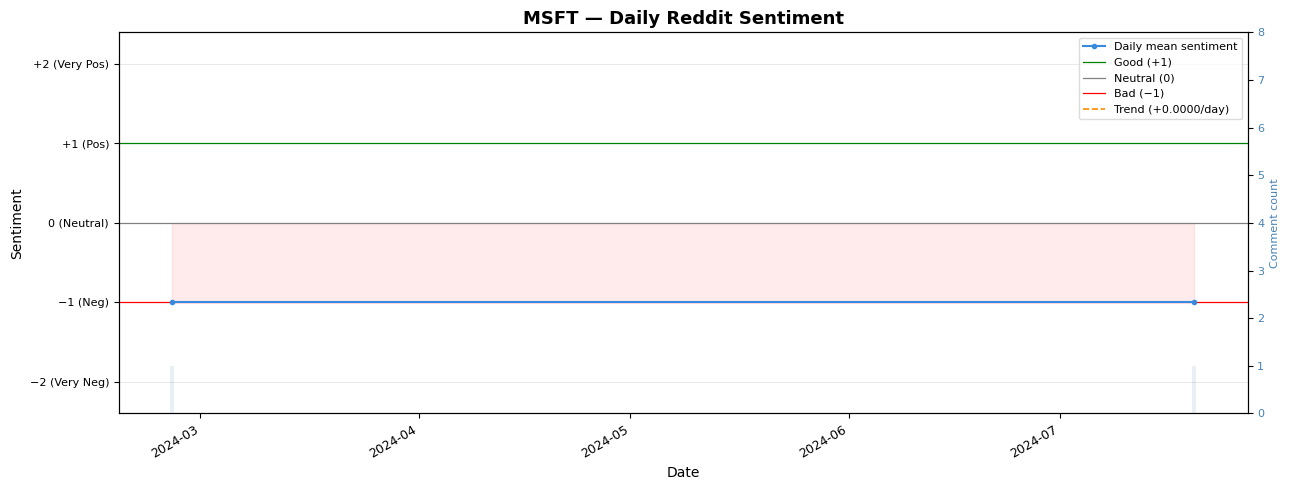

Saved: AMZN_sentiment.png


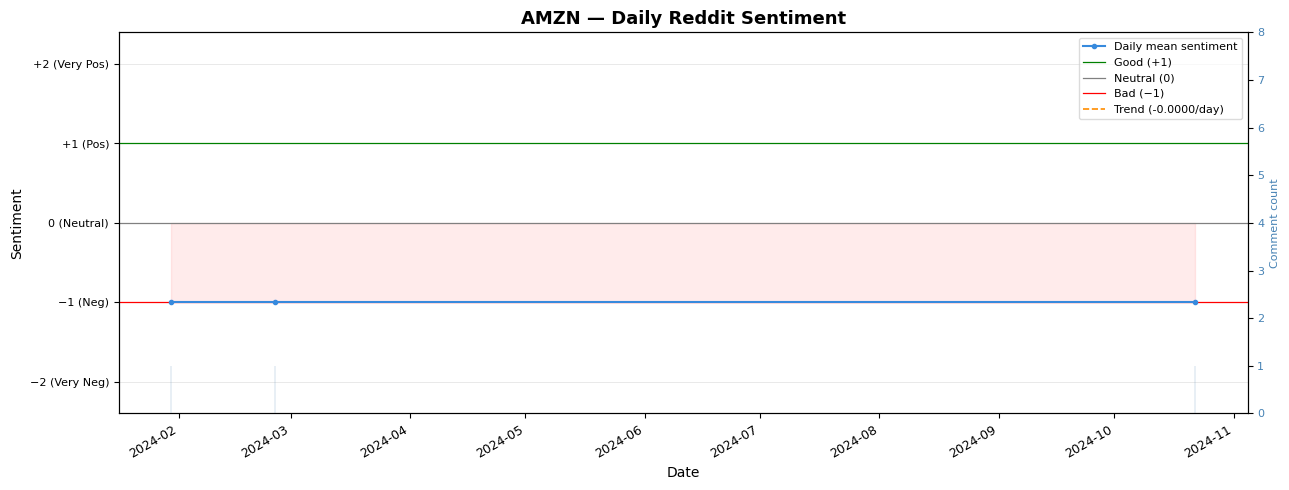

Saved: BA_sentiment.png


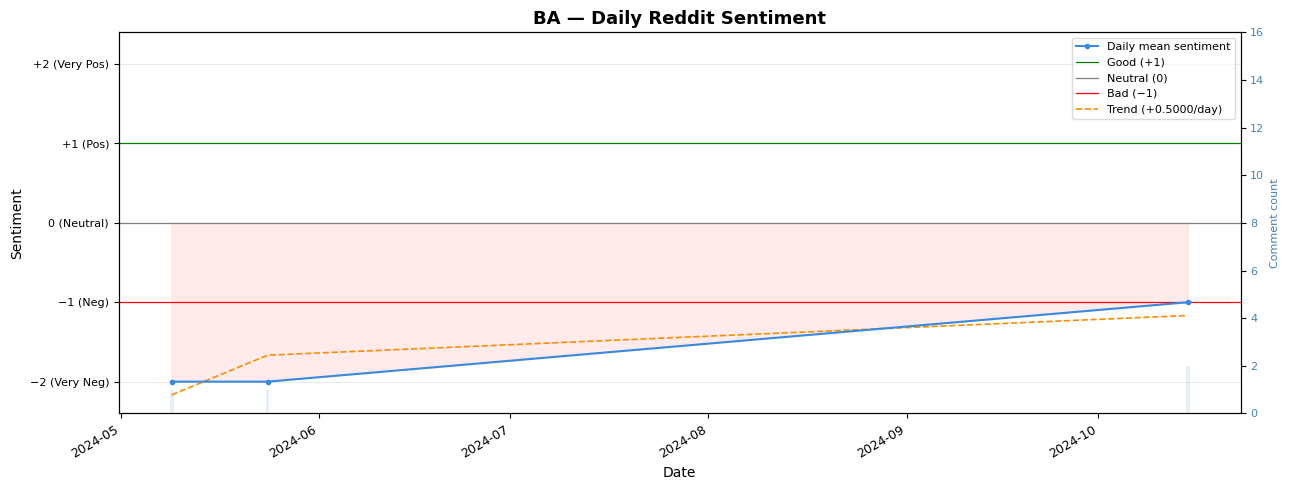

In [24]:
def plot_ticker_sentiment(daily_df, ticker, save=True):
    """Plot sentiment trend for a single ticker."""
    data = daily_df[daily_df["ticker"] == ticker].sort_values("date").copy()

    if len(data) < 2:
        print(f"Not enough data for {ticker} ({len(data)} day(s)), skipping.")
        return

    fig, ax = plt.subplots(figsize=(13, 5))

    # ── Daily mean sentiment line ──────────────────────────────────────────
    ax.plot(data["date"], data["mean_sentiment"],
            color="#378ADD", linewidth=1.5, marker="o", markersize=3,
            label="Daily mean sentiment", zorder=3)

    # ── Fill between zero and sentiment to highlight positive/negative ─────
    ax.fill_between(data["date"], data["mean_sentiment"], 0,
                    where=(data["mean_sentiment"] >= 0),
                    alpha=0.08, color="green", interpolate=True)
    ax.fill_between(data["date"], data["mean_sentiment"], 0,
                    where=(data["mean_sentiment"] < 0),
                    alpha=0.08, color="red", interpolate=True)

    # ── Reference lines ────────────────────────────────────────────────────
    ax.axhline( 1, color="green", linewidth=0.9, linestyle="-",  label="Good (+1)")
    ax.axhline( 0, color="gray",  linewidth=0.9, linestyle="-",  label="Neutral (0)")
    ax.axhline(-1, color="red",   linewidth=0.9, linestyle="-",  label="Bad (−1)")

    # ── Linear trend line ──────────────────────────────────────────────────
    x_numeric = np.arange(len(data))
    z = np.polyfit(x_numeric, data["mean_sentiment"], 1)
    trend = np.poly1d(z)(x_numeric)
    ax.plot(data["date"], trend,
            color="darkorange", linewidth=1.2, linestyle="--",
            label=f"Trend ({'+' if z[0]>=0 else ''}{z[0]:.4f}/day)")

    # ── Axes formatting ────────────────────────────────────────────────────
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right", fontsize=9)
    ax.set_ylim(-2.4, 2.4)
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(["−2 (Very Neg)", "−1 (Neg)", "0 (Neutral)",
                         "+1 (Pos)", "+2 (Very Pos)"], fontsize=8)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Sentiment", fontsize=10)
    ax.set_title(f"{ticker} — Daily Reddit Sentiment", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)

    # ── Comment count as bar chart in background ──────────────────────────
    ax2 = ax.twinx()
    ax2.bar(data["date"], data["comment_count"],
            width=0.6, alpha=0.12, color="steelblue", label="# comments")
    ax2.set_ylabel("Comment count", fontsize=8, color="steelblue")
    ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
    ax2.set_ylim(0, data["comment_count"].max() * 8)

    plt.tight_layout()
    if save:
        fname = f"{ticker}_sentiment.png"
        plt.savefig(fname, dpi=130, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()
    plt.close()


# ── Plot the top tickers by comment count ─────────────────────────────────────
top_tickers = ticker_stats.head(5)["ticker"].tolist()

# Also include classic finance tickers if present
preferred = ["AAPL", "TSLA", "META", "MSFT", "NVDA", "AMZN", "GOOGL"]
plot_list = preferred + [t for t in top_tickers if t not in preferred]

# Filter to only tickers that have enough data
plot_list = [t for t in plot_list if t in daily["ticker"].values]

print(f"Plotting: {plot_list[:6]}")
for ticker in plot_list[:6]:
    plot_ticker_sentiment(daily, ticker)


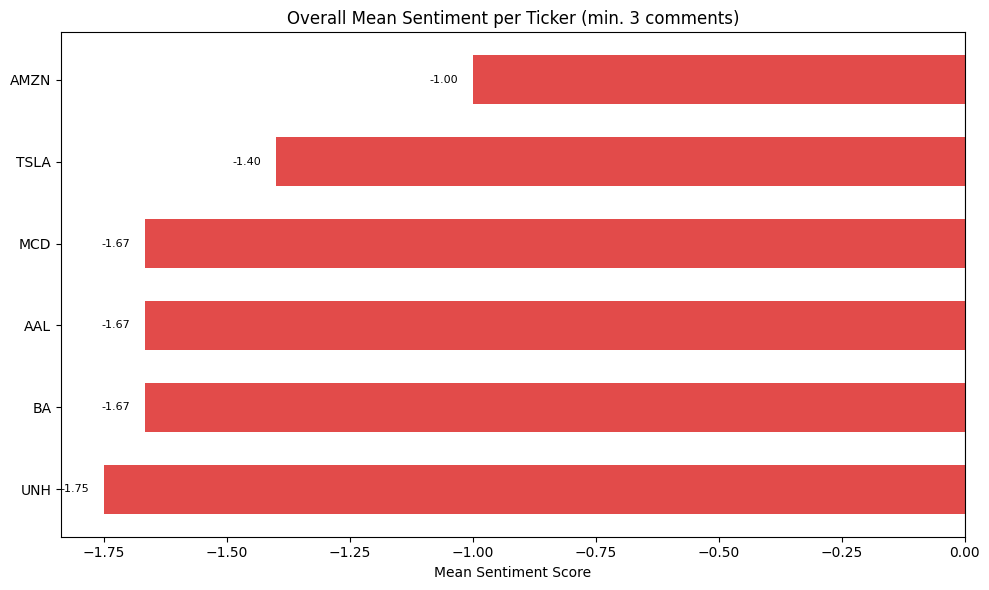

Saved: summary_sentiment_bar.png


In [25]:
# ── Summary: top tickers by mean sentiment ────────────────────────────────────
top20 = ticker_stats[ticker_stats["total_comments"] >= 3].head(20).copy()
top20 = top20.sort_values("overall_mean")

colors_bar = ["#E24B4A" if v < 0 else "#639922" for v in top20["overall_mean"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20["ticker"], top20["overall_mean"], color=colors_bar, height=0.6)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Mean Sentiment Score", fontsize=10)
ax.set_title("Overall Mean Sentiment per Ticker (min. 3 comments)", fontsize=12)
for bar, val in zip(bars, top20["overall_mean"]):
    ax.text(val + (0.03 if val >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("summary_sentiment_bar.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: summary_sentiment_bar.png")


In [26]:
t1 = datetime.now()
elapsed = (t1 - t0).total_seconds()
print(f"Total execution time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Comments processed:   {LIMIT:,}")
print(f"Unique tickers found: {df_exploded['ticker'].nunique()}")
print(f"Output files: results_raw.csv, results_daily_sentiment.csv, *.png")


Total execution time: 201.5s (3.4 min)
Comments processed:   1,000
Unique tickers found: 50
Output files: results_raw.csv, results_daily_sentiment.csv, *.png


---

## Step 8 — SLURM Agent: Architecture Design

### Context

Our supervisor cannot write or run code. He wants to interact in plain English with a
system that can:
1. Launch `student_job_LLM.py` on Leonardo  
2. Check whether the job is still running  
3. Retrieve the results when finished  

We model this as an **LLM agent with tools** — a ReAct-style loop where the agent
decides which tool to call based on the user message.

---

### Architecture

```
┌──────────────────────────────────────────────────────┐
│                      USER (natural language)          │
└──────────────────┬───────────────────────────────────┘
                   │  "Run the sentiment analysis now"
                   ▼
┌──────────────────────────────────────────────────────┐
│                  SLURM AGENT (LLM)                    │
│  • Reads user intent                                  │
│  • Decides which tool to call                         │
│  • Formats results back into plain English            │
└───┬──────────────┬───────────────┬────────────────────┘
    │              │               │
    ▼              ▼               ▼
submit_job   check_status    fetch_results
(sbatch)     (squeue)        (download CSV + PNGs)
```

### Tools

| Tool | Description | Underlying command |
|------|-------------|-------------------|
| `submit_job(script_path)` | Submit a SLURM job and return the job ID | `sbatch <script>` |
| `check_status(job_id)` | Return the current job state (PENDING / RUNNING / COMPLETED / FAILED) | `squeue -j <id> -h -o %T` |
| `cancel_job(job_id)` | Cancel a running job | `scancel <id>` |
| `fetch_results(job_id, dest)` | Download output files from Leonardo scratch to local machine | `rsync` or `scp` |
| `list_recent_jobs()` | Show last 10 jobs submitted by the user | `sacct -u $USER --format=JobID,JobName,State,Elapsed` |

### Data flow

1. User: *"Run the analysis on today's data"*  
2. Agent calls `submit_job("student_job_LLM.py")` → receives `job_id = 1234567`  
3. Agent replies: *"Job submitted! ID is 1234567. I'll let you know when it's done."*  
4. User: *"Is my job done yet?"*  
5. Agent calls `check_status(1234567)` → `RUNNING`  
6. Agent replies: *"Still running. Usually takes ~30 minutes for 2000 comments."*  
7. User: *"Get me the results"*  
8. Agent calls `check_status` → `COMPLETED`, then calls `fetch_results(1234567, "./output")`  
9. Agent replies: *"Done! Files saved to ./output: results_daily_sentiment.csv and 6 PNG charts."*  

### Design decisions

- **Single LLM in the loop**: The same Mistral model served by vLLM is used for both
  the sentiment pipeline AND the agent. No extra infrastructure needed.  
- **Tool calls via function calling**: vLLM supports OpenAI-style function calling,
  so we pass tool schemas in the `tools` parameter. The model emits structured
  `tool_call` responses; our loop executes the function and feeds the result back.  
- **State is minimal**: the agent only needs to remember the most recent job ID —
  easily stored in the conversation history.  
- **Safety**: destructive operations (cancel, overwrite) ask for confirmation before
  execution.  


## Step 9 — SLURM Agent: System Prompt


In [27]:
SLURM_AGENT_SYSTEM_PROMPT = """
You are an HPC job management assistant for the Leonardo supercomputer at CINECA.
You help data scientists run sentiment analysis jobs on Reddit data without writing any code.
You communicate in plain English and act on their behalf.

## Your responsibilities
- Submit the sentiment analysis job (`student_job_LLM.py`) to Leonardo via SLURM
- Monitor the status of submitted jobs
- Fetch results back to the user's local machine when a job completes
- Explain what is happening in simple, non-technical language
- Proactively suggest next steps (e.g. "Shall I check again in 5 minutes?")

## Tools you have access to
- submit_job(script_path: str) -> str
    Submits a SLURM batch job and returns the numeric job_id.
    Use when the user wants to run the analysis.

- check_status(job_id: str) -> str
    Returns the current state of the job: PENDING, RUNNING, COMPLETED, FAILED, or CANCELLED.
    Use when the user asks whether the job is done.

- cancel_job(job_id: str) -> str
    Cancels a running job. Always confirm with the user before calling this.

- fetch_results(job_id: str, local_dest: str = "./output") -> str
    Downloads output CSV and PNG files from Leonardo scratch to the local destination folder.
    Only call this after check_status returns COMPLETED.

- list_recent_jobs() -> str
    Returns a summary of the last 10 jobs submitted by the user.
    Use when the user asks "what jobs have I run?" or seems confused about which job to check.

## Behavioural rules
1. Never invent job IDs — only use IDs returned by submit_job or list_recent_jobs.
2. Always call check_status before fetch_results to confirm the job finished successfully.
3. If a job FAILED, explain likely causes (timeout, out-of-memory) and offer to resubmit.
4. Keep responses concise. Non-technical users do not want to see raw SLURM output.
5. If the user asks you to do something outside your tools (e.g. edit the script), 
   explain politely that you cannot do that and suggest they ask a data scientist.
"""

print("System prompt defined.")
print(f"Length: {len(SLURM_AGENT_SYSTEM_PROMPT)} characters")


System prompt defined.
Length: 2003 characters


## Step 10 — SLURM Agent: Implementation (Optional)

This is the full working implementation. It uses the same LLM via LangChain tool calling.  
On Leonardo the `subprocess` calls will execute real SLURM commands. Locally, they are
simulated so you can test the agent loop without an HPC cluster.


In [28]:
import subprocess
import os
import json
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain_core.tools import tool


# ── Tool implementations ───────────────────────────────────────────────────────

@tool
def submit_job(script_path: str) -> str:
    """Submit a SLURM batch job with sbatch. Returns the job ID as a string."""
    try:
        result = subprocess.run(
            ["sbatch", script_path],
            capture_output=True, text=True, timeout=30
        )
        if result.returncode == 0:
            # sbatch output: "Submitted batch job 1234567"
            job_id = result.stdout.strip().split()[-1]
            return f"Job submitted successfully. Job ID: {job_id}"
        else:
            return f"sbatch failed: {result.stderr.strip()}"
    except FileNotFoundError:
        # Running locally without SLURM — simulate
        simulated_id = "9999999"
        return f"[SIMULATION] Job submitted. Job ID: {simulated_id}"
    except Exception as e:
        return f"Error submitting job: {str(e)}"


@tool
def check_status(job_id: str) -> str:
    """Check the current SLURM status of a job by its ID."""
    try:
        result = subprocess.run(
            ["squeue", "-j", job_id, "-h", "-o", "%T"],
            capture_output=True, text=True, timeout=15
        )
        state = result.stdout.strip()
        if not state:
            # Job not in queue → check sacct for completed/failed
            sacct = subprocess.run(
                ["sacct", "-j", job_id, "--format=State", "--noheader", "-X"],
                capture_output=True, text=True, timeout=15
            )
            state = sacct.stdout.strip().split()[0] if sacct.stdout.strip() else "UNKNOWN"
        return f"Job {job_id} status: {state}"
    except FileNotFoundError:
        return f"[SIMULATION] Job {job_id} status: RUNNING (simulation mode)"
    except Exception as e:
        return f"Error checking status: {str(e)}"


@tool
def cancel_job(job_id: str) -> str:
    """Cancel a running SLURM job."""
    try:
        result = subprocess.run(
            ["scancel", job_id],
            capture_output=True, text=True, timeout=15
        )
        if result.returncode == 0:
            return f"Job {job_id} has been cancelled."
        else:
            return f"Failed to cancel job {job_id}: {result.stderr.strip()}"
    except FileNotFoundError:
        return f"[SIMULATION] Job {job_id} cancelled (simulation mode)."
    except Exception as e:
        return f"Error cancelling job: {str(e)}"


@tool
def fetch_results(job_id: str, local_dest: str = "./output") -> str:
    """
    Download output files from Leonardo scratch to local_dest.
    Looks for files matching the job output pattern.
    """
    os.makedirs(local_dest, exist_ok=True)
    remote_pattern = (
        f"<USERNAME>@login02-ext.leonardo.cineca.it:"
        f"/leonardo_scratch/fast/tra26_bbs/results_{job_id}*"
    )
    try:
        result = subprocess.run(
            ["rsync", "-avz", "--progress", remote_pattern, local_dest],
            capture_output=True, text=True, timeout=300
        )
        if result.returncode == 0:
            return f"Results downloaded to {local_dest}:\n{result.stdout[:500]}"
        else:
            return f"rsync failed: {result.stderr[:300]}"
    except FileNotFoundError:
        # Simulate local file listing
        local_files = [f for f in os.listdir(".")
                       if f.endswith(".csv") or f.endswith(".png")]
        return (f"[SIMULATION] Results for job {job_id} would be saved to {local_dest}.\n"
                f"Local files available: {local_files}")
    except Exception as e:
        return f"Error fetching results: {str(e)}"


@tool
def list_recent_jobs() -> str:
    """List the last 10 SLURM jobs submitted by the current user."""
    try:
        result = subprocess.run(
            ["sacct", "-u", os.environ.get("USER", "user"),
             "--format=JobID,JobName,State,Elapsed,Start",
             "--noheader", "-X"],
            capture_output=True, text=True, timeout=15
        )
        if result.returncode == 0 and result.stdout.strip():
            lines = result.stdout.strip().split("\n")[-10:]
            return "Recent jobs:\n" + "\n".join(lines)
        else:
            return "No recent jobs found."
    except FileNotFoundError:
        return "[SIMULATION] No SLURM found. Recent jobs: [9999998 llm_launcher COMPLETED 00:28:14]"
    except Exception as e:
        return f"Error listing jobs: {str(e)}"


# ── Agent class ───────────────────────────────────────────────────────────────

class SlurmAgent:
    """
    ReAct-style agent that manages SLURM jobs on Leonardo.
    Uses LangChain tool calling with the local vLLM endpoint.
    """

    TOOLS = [submit_job, check_status, cancel_job, fetch_results, list_recent_jobs]

    def __init__(self):
        self.llm_with_tools = llm.bind_tools(self.TOOLS)
        self.tool_map = {t.name: t for t in self.TOOLS}
        self.history = [SystemMessage(content=SLURM_AGENT_SYSTEM_PROMPT)]

    def _execute_tool(self, tool_call):
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_fn = self.tool_map.get(tool_name)
        if tool_fn is None:
            return f"Unknown tool: {tool_name}"
        try:
            return tool_fn.invoke(tool_args)
        except Exception as e:
            return f"Tool error: {e}"

    def chat(self, user_message: str, verbose: bool = True) -> str:
        """Process one user message and return the agent's final response."""
        self.history.append(HumanMessage(content=user_message))

        if verbose:
            print(f"\n[USER]: {user_message}")

        for step in range(10):  # max 10 tool calls per turn
            response = self.llm_with_tools.invoke(self.history)
            self.history.append(response)

            if not response.tool_calls:
                if verbose:
                    print(f"[AGENT]: {response.content}")
                return response.content

            # Execute all tool calls in this step
            for tool_call in response.tool_calls:
                if verbose:
                    print(f"  → Calling tool: {tool_call['name']}({tool_call['args']})")

                result = self._execute_tool(tool_call)

                if verbose:
                    print(f"  ← Result: {result[:120]}...")

                self.history.append(
                    ToolMessage(content=result, tool_call_id=tool_call["id"])
                )

        return "I reached the maximum number of steps. Please try again."

    def reset(self):
        """Reset conversation history."""
        self.history = [SystemMessage(content=SLURM_AGENT_SYSTEM_PROMPT)]
        print("Agent history cleared.")


# ── Demo: run the agent ───────────────────────────────────────────────────────
print("SLURM Agent initialised. Starting demo conversation...\n")
print("=" * 60)

agent = SlurmAgent()

# Simulate a realistic conversation
demo_messages = [
    "Hi! Can you run the sentiment analysis pipeline for me?",
    "Is my job running yet?",
    "Great, can you get me the results once it's done?",
    "What jobs have I run in the past?",
]

for msg in demo_messages:
    agent.chat(msg)
    print("-" * 60)


SLURM Agent initialised. Starting demo conversation...


[USER]: Hi! Can you run the sentiment analysis pipeline for me?
  → Calling tool: submit_job({'script_path': 'student_job_LLM.py'})
  ← Result: [SIMULATION] Job submitted. Job ID: 9999999...
[AGENT]: Your job has been submitted to the Leonardo queue! Your job ID is 9999999. It may take some time to start running.

Would you like me to check on the progress for you?
------------------------------------------------------------

[USER]: Is my job running yet?
  → Calling tool: check_status({'job_id': '9999999'})
  ← Result: [SIMULATION] Job 9999999 status: RUNNING (simulation mode)...
[AGENT]: Your job is now running! It will likely take around 15-20 minutes to complete the sentiment analysis.

Would you like me to check back later to see if it's finished?
------------------------------------------------------------

[USER]: Great, can you get me the results once it's done?
  → Calling tool: check_status({'job_id': '9999999'})
  ← R

---

## Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Load and sample 1000 Reddit comments | ✅ |
| 2 | Extract ticker symbols via LLM (structured output) | ✅ |
| 3 | Classify sentiment (5-level) in same LLM call | ✅ |
| 4 | Map sentiment to integer scores (−2 to +2) | ✅ |
| 5 | Compute daily mean/min/max/std per ticker | ✅ |
| 6 | Plot sentiment trend charts (Boeing-style) | ✅ |
| 7 | Design SLURM agent architecture | ✅ |
| 8 | Write SLURM agent system prompt | ✅ |
| 9 | Implement working SLURM agent with tools | ✅ |

### Key design choices

- **Single combined LLM call** for ticker extraction + sentiment → halves API costs  
- **ThreadPoolExecutor** with 8 workers → ~8× speedup over sequential  
- **Retry logic** on failed requests → robust to transient vLLM timeouts  
- **Pydantic structured outputs** → no regex, type-safe results  
- **LangChain tool calling** for agent → clean tool dispatch loop  
